## Visualize RMSE evolution with different 3DVar layers

### Environment Setup

In [3]:
# Import package
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt

# Path setup

root_path: Path = Path("/Users/joseph/Desktop/NTU Course/114-2/Data Assimilation/Project")
file_path: Path = root_path / "Files"
fig_path : Path = root_path / "Figure"


### Load data

In [4]:
# Load RMSE from different experiment
exp_list: list[str] = ["X", "Y", "Z", "X-Y-Z"] # list for layers

bec_type: str = "NMC" # "climatology" or "NMC"
var_type: str = "incremental_3DVar" # "3DVar" or "incremental_3DVar"

# Load free run RMSE

# Load experiment RMSE
rmse_dict: dict[str, dict[str,np.ndarray]] = {
    exp : dict(np.load(file_path / "rmse" / f"{var_type}_on_{exp}_{bec_type}.npz"))
    for exp in exp_list
}

rmse_dict["free"] = dict(
    np.load(file_path / "free_run_RMSE.npz")
)

# update exp_list
exp_list = list(rmse_dict.keys())


### Visualization

#### Global setting

In [5]:
plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "figure.dpi": 300,
        "axes.grid": False,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.constrained_layout.use": True
    })

#### Time coordinate

In [6]:
# temporal configuration
dt    : float = 0.01  
t_eval: float = 50.0  

# skipping when visualizing
skips: int = 40

# time coordinate
t_coord: np.ndarray = np.arange(0, t_eval, dt)[:2000]

#### Generate figure

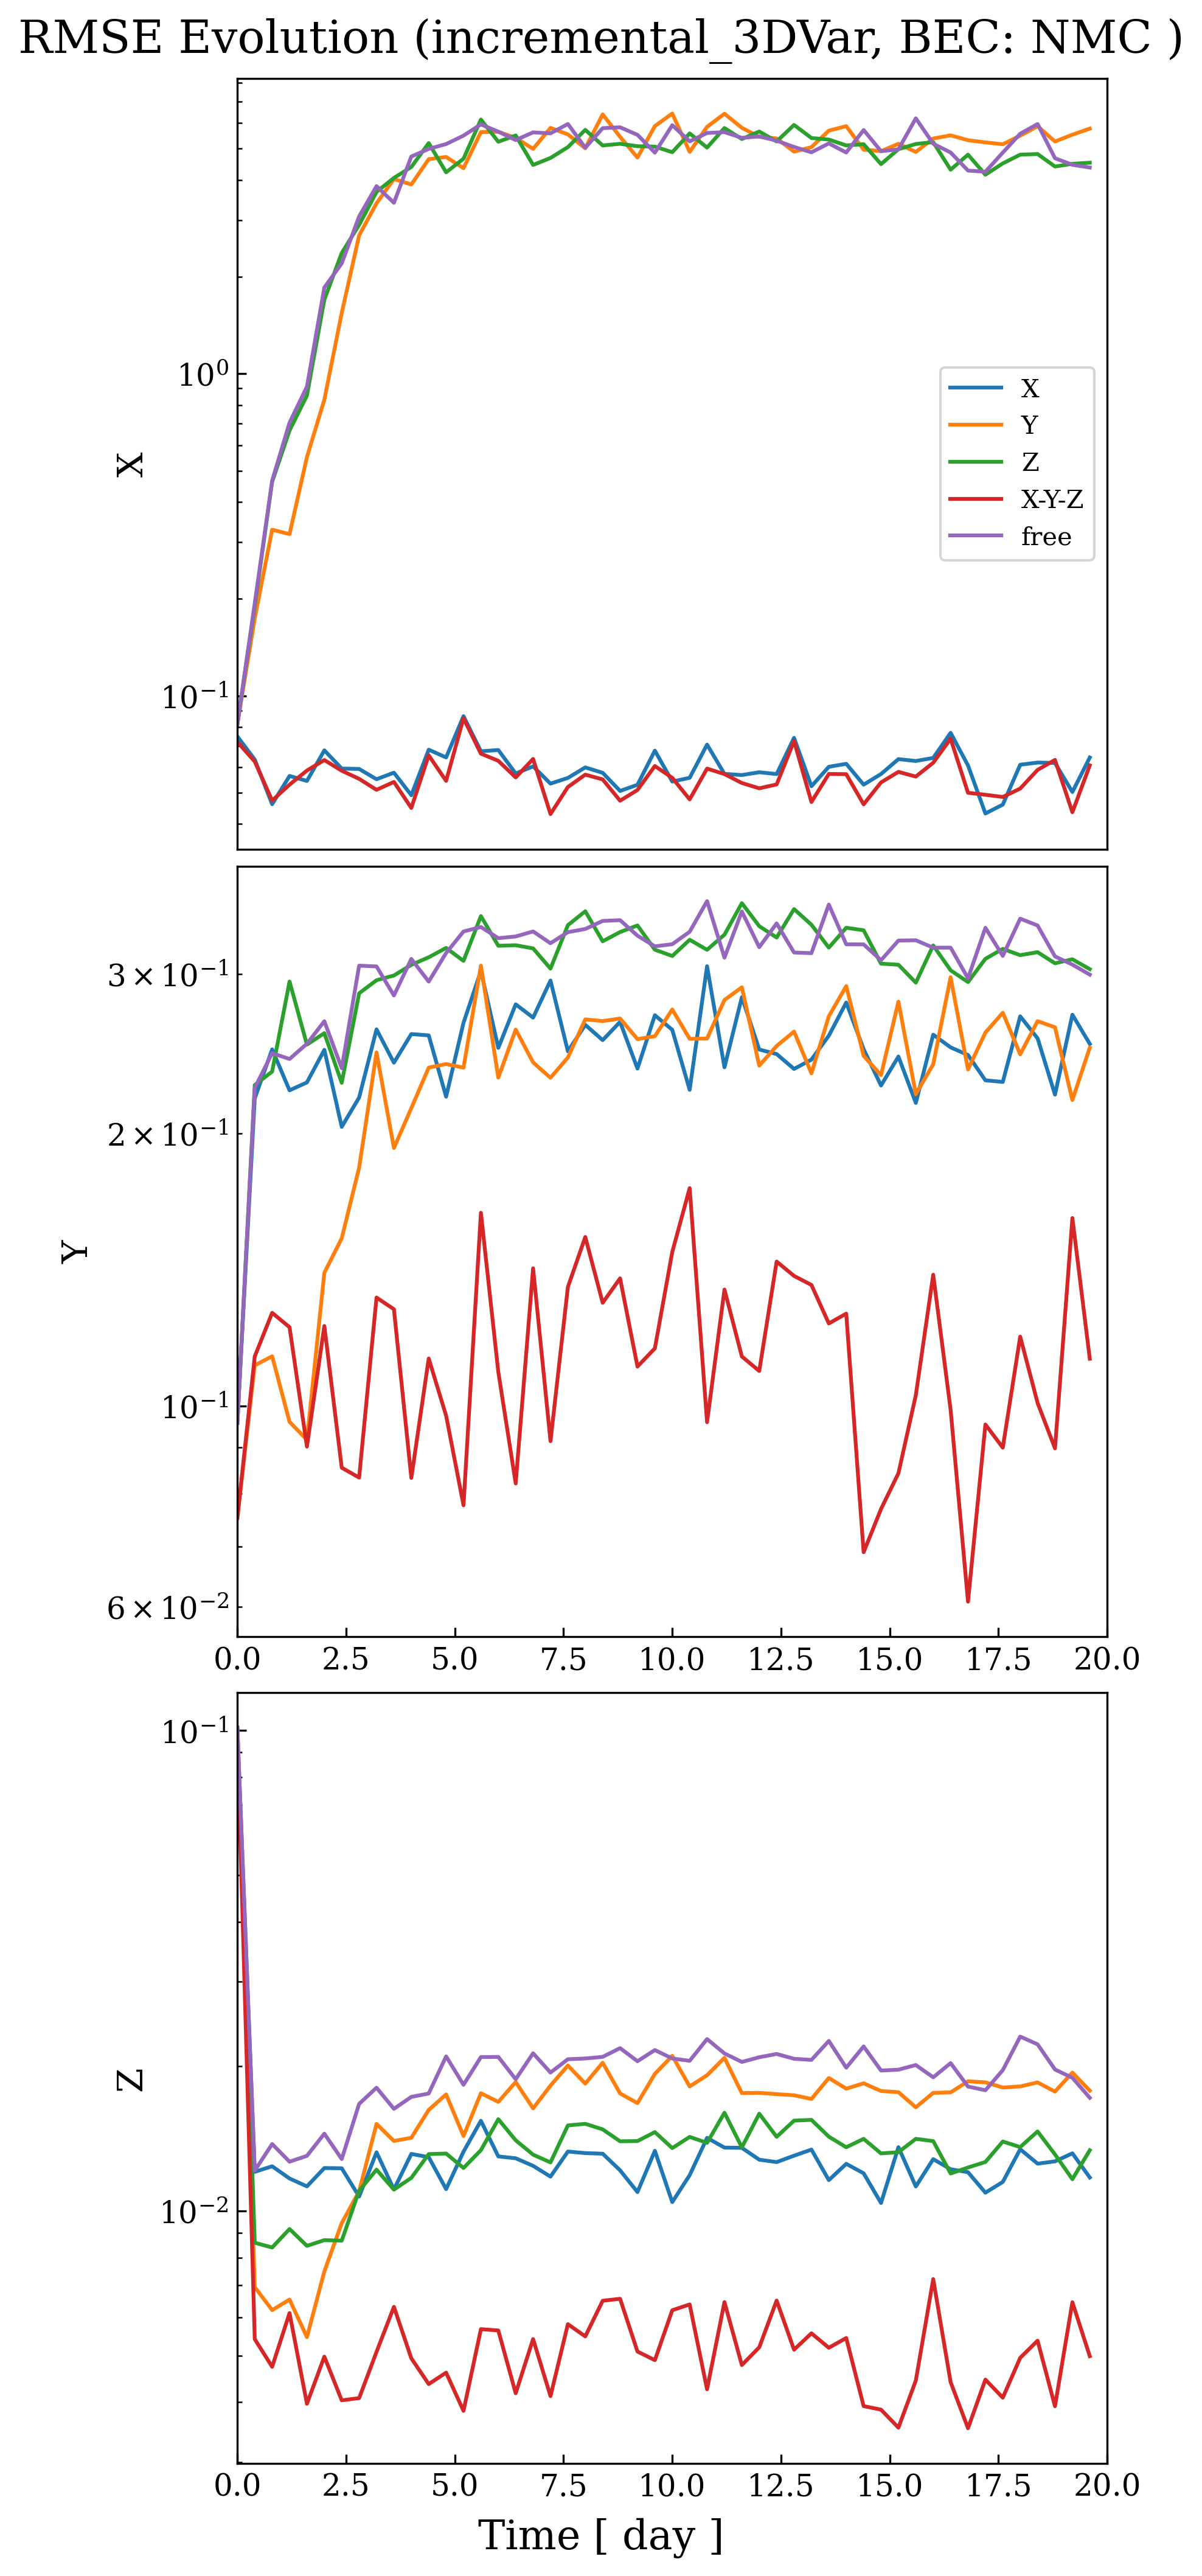

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(6, 14))

# Plot contrast of RMSE

for exp in exp_list:
    axes[0].semilogy(
        t_coord[::skips], rmse_dict[exp]["X"][:2000][::skips],
        label=exp
    )
    axes[1].semilogy(
        t_coord[::skips], rmse_dict[exp]["Y"][:2000][::skips]
    )
    axes[2].semilogy(
        t_coord[::skips], rmse_dict[exp]["Z"][:2000][::skips]
    )

axes[0].set_xticks([])

axes[0].set_xlim(0, 20)
axes[1].set_xlim(0, 20)
axes[2].set_xlim(0, 20)

axes[0].set_ylabel("X")
axes[1].set_ylabel("Y")
axes[2].set_ylabel("Z")

axes[0].legend()

fig.supxlabel("Time [ day ]", fontsize=16)
fig.suptitle(f"RMSE Evolution ({var_type}, BEC: {bec_type} )", fontsize=18)

plt.savefig(fig_path / "RMSE_compare" / f"{var_type}_{bec_type}.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)